# A Simple Neural Network from Scratch using NumPy

In this notebook, we will implement a minimal neural network using only Python and NumPy — without relying on any machine learning libraries such as TensorFlow or PyTorch.

We aim to solve a fundamental problem in binary classification: learning the behavior of the **OR logic gate** using a neural network. The OR gate outputs `1` if at least one of its inputs is `1`, and outputs `0` otherwise. Its truth table is as follows:

\begin{array}{|c|c|c|}
\hline
\text{Input 1} & \text{Input 2} & \text{Output (Label)} \\
\hline
0 & 0 & 0 \\
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 1 \\
\hline
\end{array}

The problem is simple and linearly separable, making it ideal for building and understanding the core components of a neural network, such as:

- Forward propagation
- Activation functions
- Loss calculation
- Backpropagation
- Gradient descent optimization

By the end of this exercise, we will have a working neural network that learns to model the OR function. This foundational project will serve as a stepping stone for understanding more complex neural network architectures and learning algorithms.

In [1]:
import numpy as np

# Logger utility
def log(msg, level="INFO"):
    print(f"[{level}] {msg}")

# Define the OR gate dataset
def load_or_data():
    try:
        # Inputs: 4 samples, 2 features
        X = np.array([[0, 0],
                      [0, 1],
                      [1, 0],
                      [1, 1]])
        # Outputs: 4 labels
        y = np.array([[0],
                      [1],
                      [1],
                      [1]])
        log("Dataset loaded successfully.")
        return X, y
    except Exception as e:
        log(f"Failed to load data: {e}", level="ERROR")
        raise

# Load the data
X, y = load_or_data()

# Verify the data
log(f"Input shape: {X.shape}, Output shape: {y.shape}")

[INFO] Dataset loaded successfully.
[INFO] Input shape: (4, 2), Output shape: (4, 1)


In [2]:
# Seed for reproducibility
np.random.seed(42)

# Initialize weights and biases
def initialize_parameters(input_dim):
    try:
        weights = np.random.randn(input_dim, 1) * 0.01  # small random values
        bias = 0.0
        log("Parameters initialized.")
        return weights, bias
    except Exception as e:
        log(f"Error in initializing parameters: {e}", level="ERROR")
        raise

# Sigmoid activation function
def sigmoid(z):
    try:
        return 1 / (1 + np.exp(-z))
    except Exception as e:
        log(f"Sigmoid computation failed: {e}", level="ERROR")
        raise

# Derivative of sigmoid (for backpropagation)
def sigmoid_derivative(a):
    try:
        return a * (1 - a)
    except Exception as e:
        log(f"Sigmoid derivative computation failed: {e}", level="ERROR")
        raise

# Initialize parameters for 2 inputs
weights, bias = initialize_parameters(input_dim=2)

log(f"Initial weights:\n{weights}")
log(f"Initial bias: {bias}")

[INFO] Parameters initialized.
[INFO] Initial weights:
[[ 0.00496714]
 [-0.00138264]]
[INFO] Initial bias: 0.0


In [3]:
# Forward propagation function
def forward_propagation(X, weights, bias):
    try:
        z = np.dot(X, weights) + bias     # Linear part
        a = sigmoid(z)                    # Activation part
        log("Forward propagation successful.")
        return a
    except Exception as e:
        log(f"Forward propagation failed: {e}", level="ERROR")
        raise

# Run forward pass with current weights
a = forward_propagation(X, weights, bias)

# Log outputs
log(f"Predicted outputs (a):\n{a}")

[INFO] Forward propagation successful.
[INFO] Predicted outputs (a):
[[0.5       ]
 [0.49965434]
 [0.50124178]
 [0.50089612]]


In [4]:
# Binary cross-entropy loss function
def compute_loss(y_true, y_pred):
    try:
        m = y_true.shape[0]
        # Add small epsilon to avoid log(0)
        epsilon = 1e-8
        loss = - (1 / m) * np.sum(
            y_true * np.log(y_pred + epsilon) + 
            (1 - y_true) * np.log(1 - y_pred + epsilon)
        )
        log(f"Loss computed: {loss:.6f}")
        return loss
    except Exception as e:
        log(f"Loss computation failed: {e}", level="ERROR")
        raise

# Compute the loss for current predictions
loss = compute_loss(y, a)

[INFO] Loss computed: 0.692252


In [5]:
# Backpropagation and parameter update
def backward_propagation(X, y_true, y_pred, weights, bias, learning_rate=0.1):
    try:
        m = X.shape[0]

        # Compute gradients
        dz = y_pred - y_true                  # derivative of loss w.r.t z
        dw = (1 / m) * np.dot(X.T, dz)        # shape (2,1)
        db = (1 / m) * np.sum(dz)             # scalar

        # Update weights and bias
        weights -= learning_rate * dw
        bias -= learning_rate * db

        log(f"Gradients computed and parameters updated.")
        return weights, bias
    except Exception as e:
        log(f"Backpropagation failed: {e}", level="ERROR")
        raise

# Single training step (for demonstration)
weights, bias = backward_propagation(X, y, a, weights, bias, learning_rate=0.1)

# Log updated parameters
log(f"Updated weights:\n{weights}")
log(f"Updated bias: {bias}")

[INFO] Gradients computed and parameters updated.
[INFO] Updated weights:
[[0.02991369]
 [0.0236036 ]]
[INFO] Updated bias: 0.024955193854959635


In [9]:
# Full training function
def train(X, y, epochs=1000, learning_rate=0.1, log_interval=100):
    try:
        # Initialize parameters
        weights, bias = initialize_parameters(X.shape[1])
        losses = []

        for epoch in range(1, epochs + 1):
            # Forward pass
            y_pred = forward_propagation(X, weights, bias)

            # Compute loss
            loss = compute_loss(y, y_pred)
            losses.append(loss)

            # Backward pass
            weights, bias = backward_propagation(X, y, y_pred, weights, bias, learning_rate)

            # Logging
            if epoch % log_interval == 0 or epoch == 1:
                log(f"Epoch {epoch}: Loss = {loss:.6f}")

        log("Training complete.")
        return weights, bias, losses
    except Exception as e:
        log(f"Training failed: {e}", level="ERROR")
        raise

# Run training
weights, bias, losses = train(X, y, epochs=3000, learning_rate=0.1, log_interval=100)

[INFO] Parameters initialized.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.687307
[INFO] Gradients computed and parameters updated.
[INFO] Epoch 1: Loss = 0.687307
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.669267
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.652548
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.637046
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.622662
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.609304
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.596886
[INFO] Gradients computed and parameters updated.
[INFO] Forward propagation successful.
[INFO] Loss computed: 0.585330
[INFO] Gradients computed a

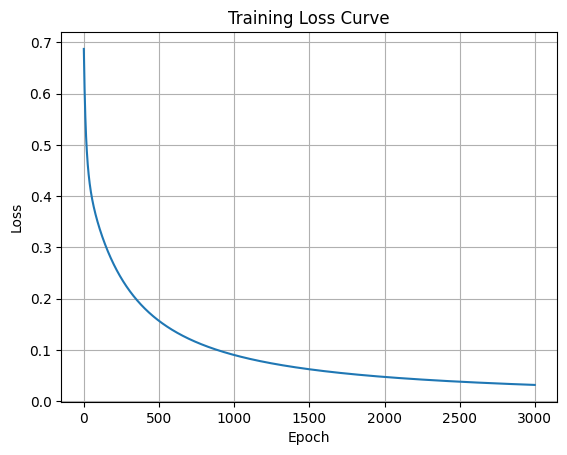

In [10]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    try:
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.grid(True)
        plt.show()
    except Exception as e:
        log(f"Loss plot failed: {e}", level="ERROR")
        raise

plot_loss_curve(losses)

In [11]:
# Predict function using trained model
def predict(X, weights, bias, threshold=0.5):
    try:
        probs = forward_propagation(X, weights, bias)
        predictions = (probs >= threshold).astype(int)
        return predictions
    except Exception as e:
        log(f"Prediction failed: {e}", level="ERROR")
        raise

# Evaluate predictions
def evaluate(predictions, targets):
    try:
        accuracy = np.mean(predictions == targets)
        log(f"Evaluation complete. Accuracy: {accuracy * 100:.2f}%")
        return accuracy
    except Exception as e:
        log(f"Evaluation failed: {e}", level="ERROR")
        raise

# Run prediction
predictions = predict(X, weights, bias)

# Show results
log(f"Predictions:\n{predictions}")
log(f"True Labels:\n{y}")

# Evaluate
accuracy = evaluate(predictions, y)

[INFO] Forward propagation successful.
[INFO] Predictions:
[[0]
 [1]
 [1]
 [1]]
[INFO] True Labels:
[[0]
 [1]
 [1]
 [1]]
[INFO] Evaluation complete. Accuracy: 100.00%
